# Proyek Klasifikasi Gambar: Weather Condition
- **Nama:** Luigi Ifan Dwiutomo
- **Email:** luigiifan@student.ppns.ac.id
- **ID Dicoding:** luigiifan13

## Import Semua Packages/Library yang Digunakan

In [ ]:
!pip install tensorflowjs

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random
from collections import defaultdict
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras.preprocessing import image
from sklearn.utils import class_weight
import tensorflow as tf
import tensorflowjs as tfjs
from keras.layers import TFSMLayer
from keras import Input, Model

2025-05-01 05:16:50.468765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746076610.669502      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746076610.725377      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Data Preparation

### Data Loading

In [3]:
# INISIALISASI LOKASI DIRECTORY DARI DATASET ASLI DAN TARGET UNTUK DATA SPLITTING.
original_dir = "/kaggle/input/multiclass-weather-dataset/Multi-class Weather Dataset"
target_dir = "/kaggle/working/dataset_split"

In [4]:
# MENAMPILKAN KELAS YANG TERSEDIA PADA DATASET.
class_names = sorted(os.listdir(original_dir))
print("Daftar Classes:", class_names)

Daftar Classes: ['Cloudy', 'Rain', 'Shine', 'Sunrise']


**Insight:**
- Menggunakan Weather Dataset yang didapatkan dari kaggle
- Terdapat 4 kelas pada dataset yang digunakan.

## Data Preprocessing

In [5]:
# DAFTAR KELAS YANG DIGUNAKAN PADA DATASET.
selected_classes = ['Cloudy', 'Rain', 'Shine', 'Sunrise']

In [6]:
# MENGHITUNG JUMLAH GAMBAR DARI SETIAP KELAS PADA DATASET.
image_counts = {}
widths = []
heights = []

for cls in selected_classes:
    class_path = os.path.join(original_dir, cls)
    image_list = [img for img in os.listdir(class_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    image_counts[cls] = len(image_list)

    for img_name in image_list:
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                widths.append(img.size[0])
                heights.append(img.size[1])
        except:
            continue

for cls, count in image_counts.items():
    print(f"{cls}: {count} gambar")

Cloudy: 300 gambar
Rain: 215 gambar
Shine: 253 gambar
Sunrise: 357 gambar


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


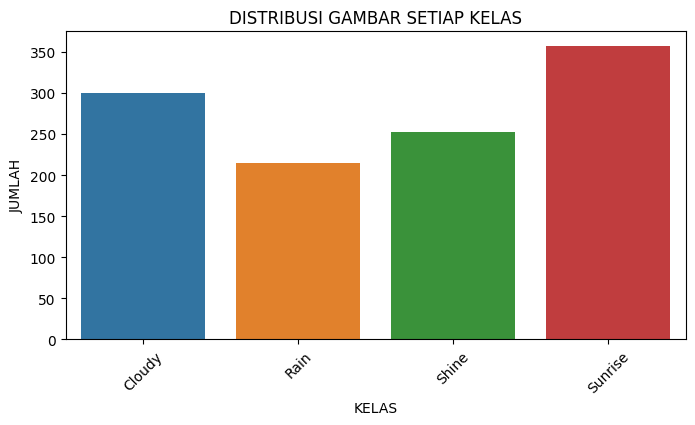

In [7]:
# MENAMPILKAN DISTRIBUSI JUMLAH GAMBAR DARI SETIAP KELAS PADA DATASET.
plt.figure(figsize=(8, 4))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()))
plt.title("DISTRIBUSI GAMBAR SETIAP KELAS")
plt.xlabel("KELAS")
plt.ylabel("JUMLAH")
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


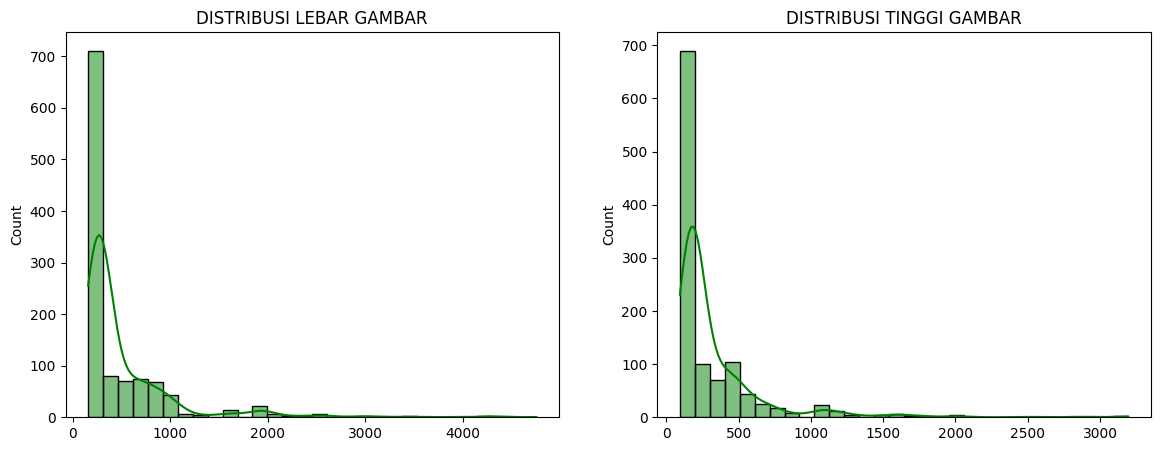

RATA-RATA UKURAN: 506.30 x 334.75 px
UKURAN MINIMUM: 158 x 94 px
UKURAN MAKSIMUM: 4752 x 3195 px


In [8]:
# MENAMPILKAN DISTRIBUSI LEBAR DAN TINGGI GAMBAR DARI DATASET.
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(widths, bins=30, kde=True, color='green')
plt.title("DISTRIBUSI LEBAR GAMBAR")
plt.subplot(1, 2, 2)
sns.histplot(heights, bins=30, kde=True, color='green')
plt.title("DISTRIBUSI TINGGI GAMBAR")
plt.show()

# MENAMPILKAN STATISTIK UKURAN DARI DATASET.
print(f"RATA-RATA UKURAN: {np.mean(widths):.2f} x {np.mean(heights):.2f} px")
print(f"UKURAN MINIMUM: {min(widths)} x {min(heights)} px")
print(f"UKURAN MAKSIMUM: {max(widths)} x {max(heights)} px")

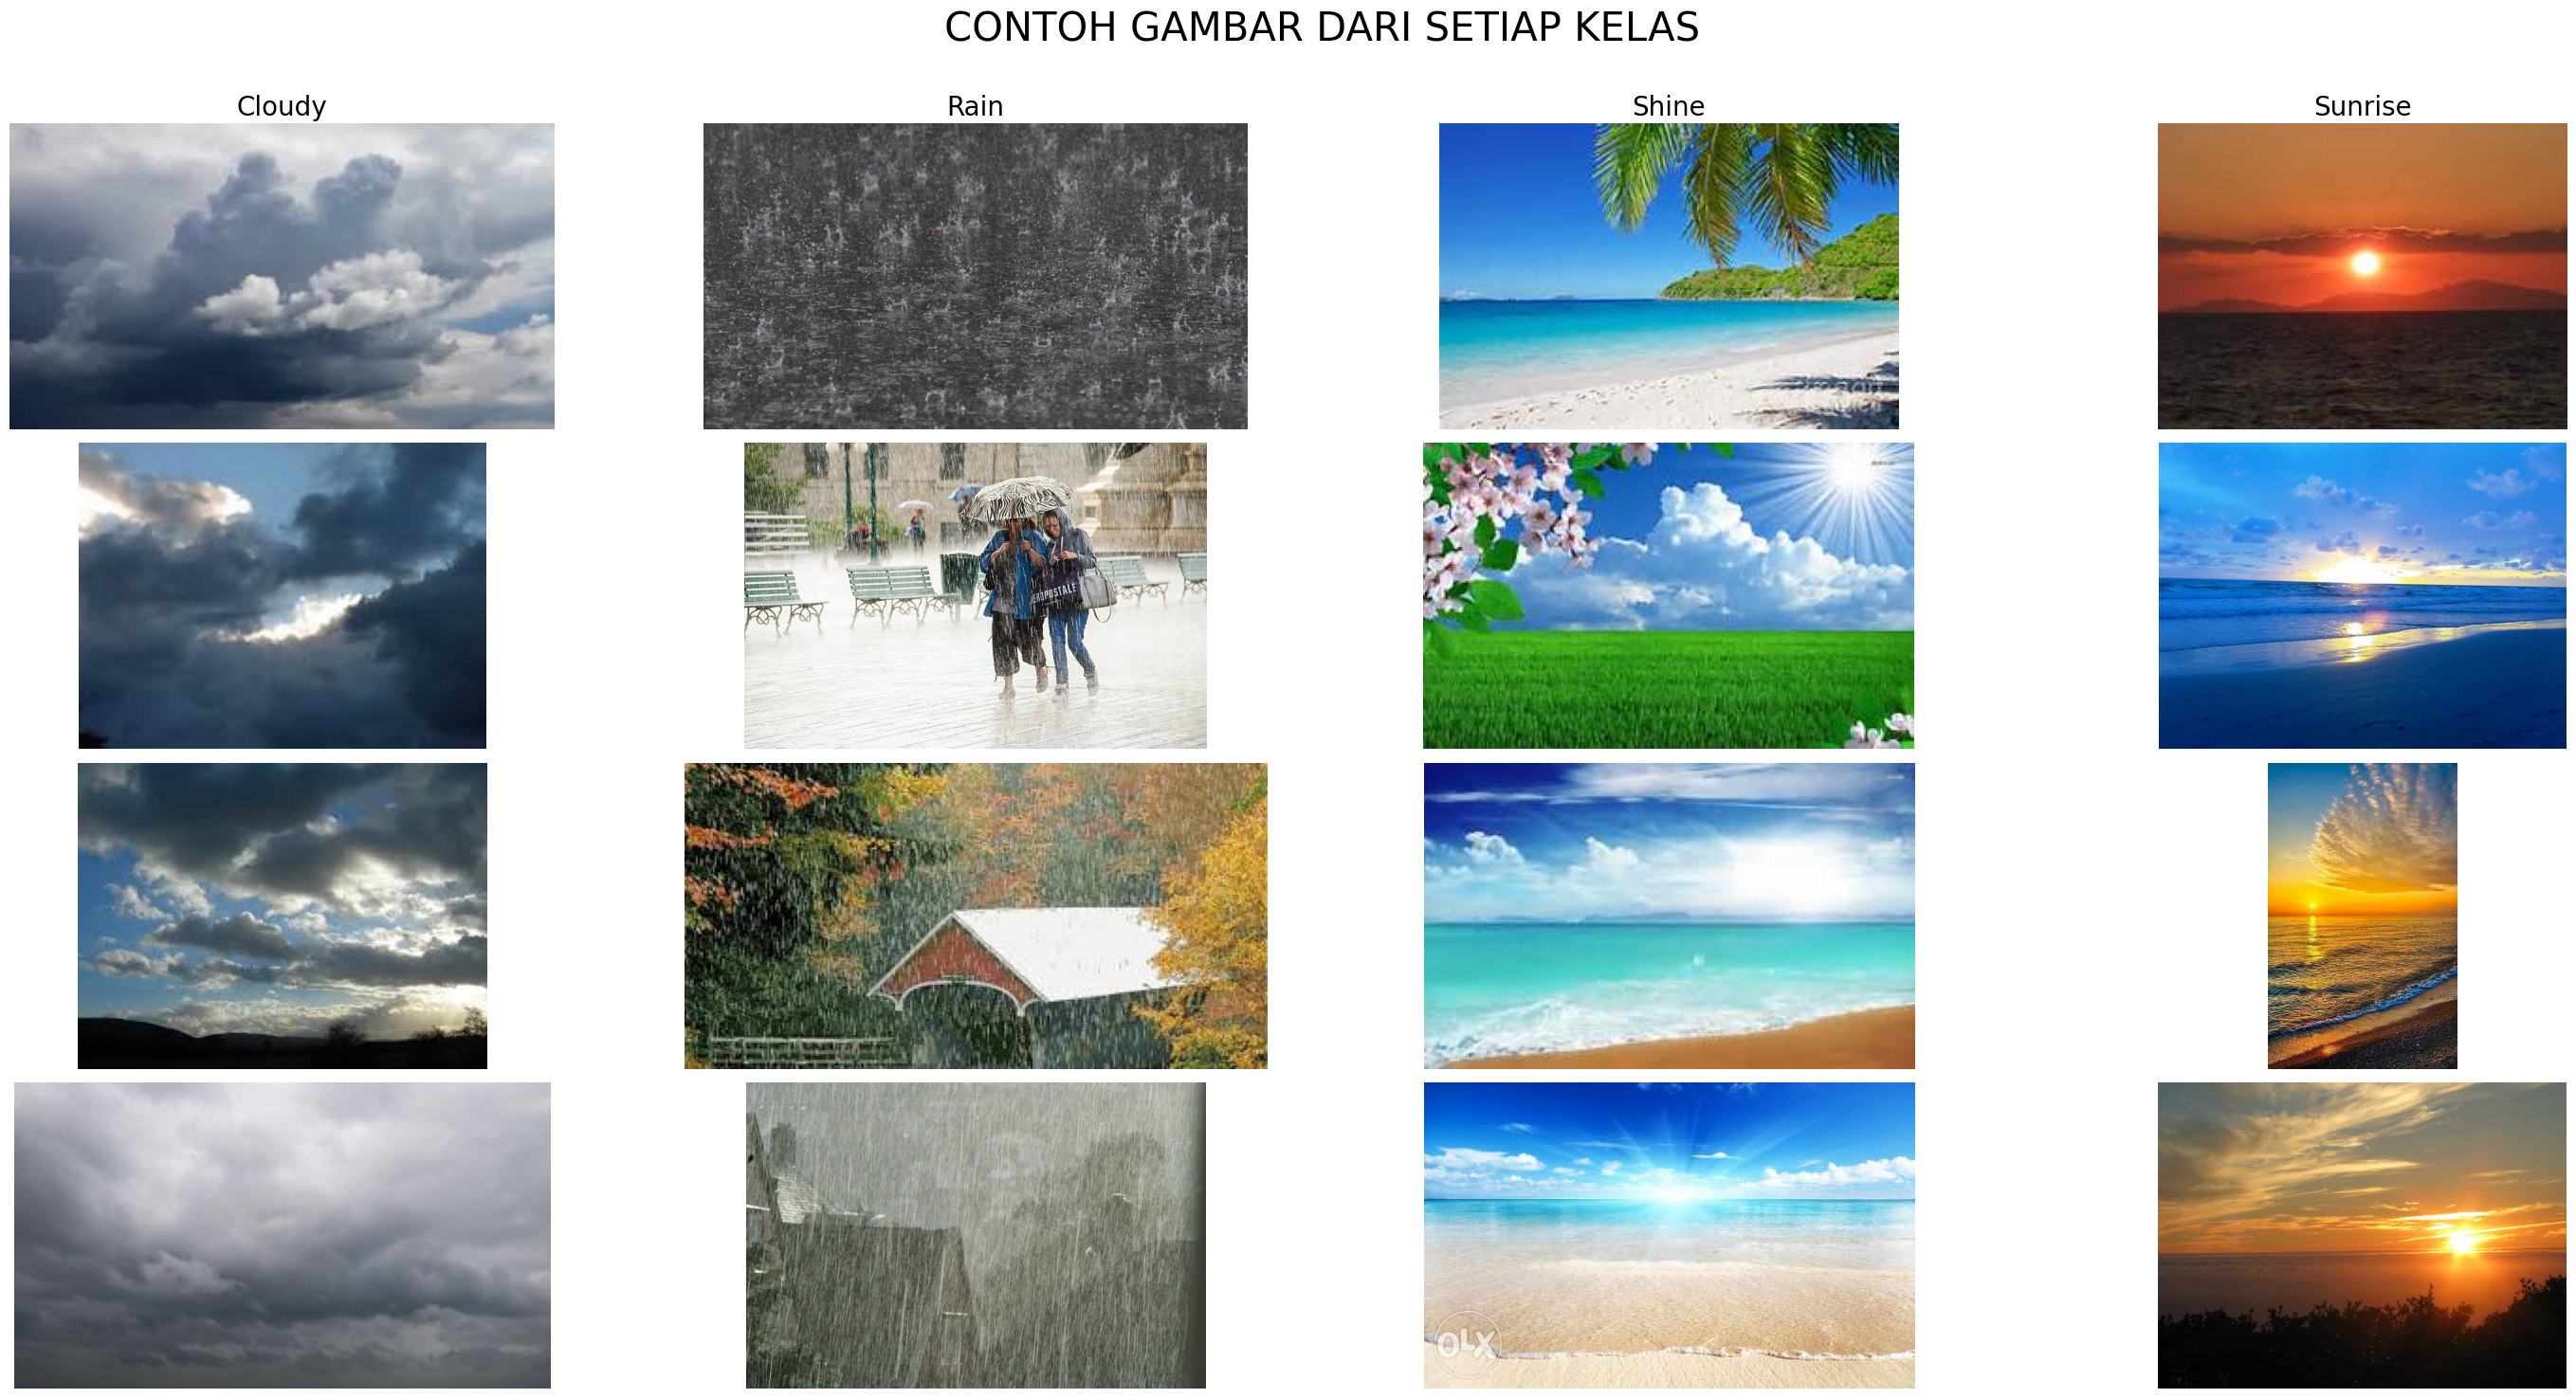

In [9]:
# MENAMPILKAN SAMPLES GAMBAR DARI SETIAP CLASSES PADA DATASET.
fig, axs = plt.subplots(4, len(selected_classes), figsize=(30, 15))

# Loop over each class
for i, cls in enumerate(selected_classes):
    class_path = os.path.join(original_dir, cls)
    sample_imgs = os.listdir(class_path)[:4]

    # Loop through the 6 sample images in each class
    for j, img_name in enumerate(sample_imgs):
        img = Image.open(os.path.join(class_path, img_name))
        axs[j, i].imshow(img)
        axs[j, i].axis('off')
        if j == 0:
            axs[j, i].set_title(cls, fontsize=20)

plt.suptitle("CONTOH GAMBAR DARI SETIAP KELAS", fontsize=30)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

**Insight:**
- Jumlah gambar dari dataset setiap kelas dengan total 1,125 gambar.
- Memiliki rata-rata ukuran gambar yang berbeda yakni 506.30 x 334.75 pixels.

### Data Splitting

In [10]:
# PARAMETER UNTUK TRAINING.
img_size = (224, 224)
batch_size = 32
num_classes = len(selected_classes)

In [11]:
# PROSES SPLITTING DATA.
for split in ['train', 'val', 'test']:
    for cls in selected_classes:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

for cls in selected_classes:
    cls_folder = os.path.join(original_dir, cls)
    images = [img for img in os.listdir(cls_folder) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

    train_img, temp_img = train_test_split(images, test_size=0.3, random_state=42)
    val_img, test_img = train_test_split(temp_img, test_size=0.5, random_state=42)

    def process_and_save(images_list, split_type):
        for img_name in images_list:
            src = os.path.join(cls_folder, img_name)
            dst = os.path.join(target_dir, split_type, cls, img_name)
            try:
                with Image.open(src) as img:
                    img = img.convert("RGB")
                    img = img.resize(img_size)
                    img.save(dst)
            except Exception as e:
                print(f"Error processing {src}: {e}")

    process_and_save(train_img, 'train')
    process_and_save(val_img, 'val')
    process_and_save(test_img, 'test')

print("DATASET TELAH DI RESIZE DAN DI SPLIT KE TRAIN, VAL DAN TEST.")

DATASET TELAH DI RESIZE DAN DI SPLIT KE TRAIN, VAL DAN TEST.


In [12]:
# DATA AUGMENTATION.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [13]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(target_dir, 'train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(target_dir, 'val'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(target_dir, 'test'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 786 images belonging to 4 classes.
Found 169 images belonging to 4 classes.
Found 170 images belonging to 4 classes.


In [14]:
# MENGAMBIL LABEL DARI TRAIN GENERATOR.
y_train = train_generator.classes

# MENGHITUNG CLASS WEIGHT BERDASARKAN DISTRIBUSI.
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# KONVERSI KE DICTIONARY UNTUK FIT.
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

Class Weights: {0: 0.9357142857142857, 1: 1.31, 2: 1.1101694915254237, 3: 0.7891566265060241}


In [15]:
class StopTrainingAt90Accuracy(Callback):
    def __init__(self, target_accuracy=0.9):
        super(StopTrainingAt90Accuracy, self).__init__()
        self.target_accuracy = target_accuracy

    def on_epoch_end(self, epoch, logs=None):
        # Jika training accuracy dan validation accuracy mencapai target
        if logs.get('accuracy') >= self.target_accuracy and logs.get('val_accuracy') >= self.target_accuracy:
            print(f"\nStopping training at epoch {epoch + 1} because accuracy and val_accuracy reached {self.target_accuracy * 100}%")
            self.model.stop_training = True

**Insight:**
- Melakukan resizing gambar dan data spitting ke train, val, dan set.
- Melakukan augmentasi pada dataset pelatihan untuk meningkatkan keberagaman data dan mencegah overfitting.

## Modelling

In [16]:
model = Sequential([
    Conv2D(64, (3,3), activation ='relu', input_shape = (224,224,3)),
    MaxPooling2D((2,2)),
    Dropout(0.3),
    Conv2D(64, (3,3), activation ='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.3),
    Conv2D(128, (3,3), activation ='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(num_classes, activation = 'softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1746076645.321392      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 111, 111, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,188,804 (42.68 MB)

 Trainable params: 11,188,804 (42.68 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# FUNGSI CALLBACK UNTUK TRAINING MODEL.
callbacks = [
    StopTrainingAt90Accuracy(target_accuracy=0.9),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

In [19]:
results = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weights_dict
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1746076653.015071      88 service.cc:148] XLA service 0x789f8800d0b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746076653.016073      88 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1746076653.400865      88 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/25 ━━━━━━━━━━━━━━━━━━━━ 4:34 11s/step - accuracy: 0.1875 - loss: 1.5911

I0000 00:00:1746076659.122273      88 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 488ms/step - accuracy: 0.3372 - loss: 3.5866 - val_accuracy: 0.5799 - val_loss: 0.8715 - learning_rate: 0.0010
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 231ms/step - accuracy: 0.6391 - loss: 0.8230 - val_accuracy: 0.7751 - val_loss: 0.6904 - learning_rate: 0.0010
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 231ms/step - accuracy: 0.7343 - loss: 0.6452 - val_accuracy: 0.7456 - val_loss: 0.6190 - learning_rate: 0.0010
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 235ms/step - accuracy: 0.6988 - loss: 0.7138 - val_accuracy: 0.8757 - val_loss: 0.5591 - learning_rate: 0.0010
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 232ms/step - accuracy: 0.7912 - loss: 0.5247 - val_accuracy: 0.7988 - val_loss: 0.5142 - learning_rate: 0.0010
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.7717 - loss: 0.5740 - val_accuracy: 0.8284 - val_loss: 0.4839 - learning_rate: 0.0010
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 230ms/step - accuracy: 0.8111 - loss: 0.5157 - val_accura

## Evaluasi dan Visualisasi

In [20]:
# Menampilkan akurasi pelatihan dan validasi
print("Akurasi pada data pelatihan:")
print("Training Accuracy:", results.history['accuracy'])

print("Akurasi pada data validasi:")
print("Validation Accuracy:", results.history['val_accuracy'])

Akurasi pada data pelatihan:
Training Accuracy: [0.4351145029067993, 0.6323155164718628, 0.7175572514533997, 0.7239185571670532, 0.7722646594047546, 0.7748091816902161, 0.7786259651184082, 0.7913485765457153, 0.796437680721283, 0.8244274854660034, 0.8409669399261475, 0.847328245639801, 0.856234073638916, 0.8638677000999451, 0.8778625726699829, 0.8702290058135986, 0.856234073638916, 0.8969465494155884, 0.910941481590271]
Akurasi pada data validasi:
Validation Accuracy: [0.5798816680908203, 0.7751479148864746, 0.7455621361732483, 0.8757396340370178, 0.7988165616989136, 0.8284023404121399, 0.834319531917572, 0.857988178730011, 0.88165682554245, 0.8284023404121399, 0.88165682554245, 0.9112426042556763, 0.7988165616989136, 0.8994082808494568, 0.8994082808494568, 0.9053254723548889, 0.9171597361564636, 0.9112426042556763, 0.9289940595626831]


In [21]:
loss, acc = model.evaluate(test_generator)
print(f"Akurasi Test: {acc*100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.8177 - loss: 0.5195
Akurasi Test: 86.47%


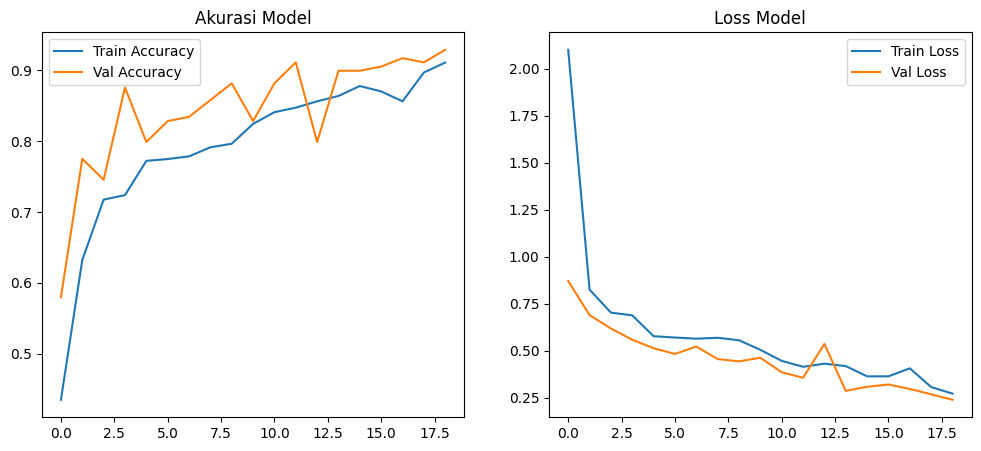

In [22]:
# Akurasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(results.history['accuracy'], label='Train Accuracy')
plt.plot(results.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Akurasi Model')

# Loss
plt.subplot(1, 2, 2)
plt.plot(results.history['loss'], label='Train Loss')
plt.plot(results.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Model')

plt.show()

**Insight:**:
- Didapatkan akurasi dari training model mencapai 91%.
- Hasil evaluasi kinerja model pada data uji didapatkan akurasi sekitar 86.47%.

## Konversi Model

In [23]:
# SavedModel
model.export('/kaggle/working/saved_model')

# TFLite
converter = tf.lite.TFLiteConverter.from_saved_model('/kaggle/working/saved_model')
tflite_model = converter.convert()
with open('/kaggle/working/model.tflite', 'wb') as f:
    f.write(tflite_model)

# TFJS
tfjs.converters.save_keras_model(model, '/kaggle/working/tfjs_model')

Saved artifact at '/kaggle/working/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  132630045070672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630045071248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630045071440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630045072400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630045071632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630045073744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630045074320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630045075472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630045075664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630045076240: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1746076820.417062      19 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1746076820.417096      19 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1746076820.424848      19 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


failed to lookup keras version from the file,
    this is likely a weight only file


**Insight:**
- Model disimpan dalam format SavedModel, TFLite, dan TFJS.

## Inference

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step


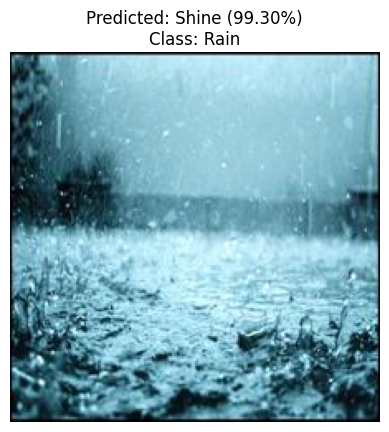

In [24]:
# PILIH KELAS RANDOM DARI FOLDER TEST.
random_class = random.choice(selected_classes)

# AMBIL GAMBAR RANDOM DARI FOLDER TEST.
test_dir = f'/kaggle/working/dataset_split/test/{random_class}'  # Path folder test untuk kelas yang dipilih
image_list = [img for img in os.listdir(test_dir) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
random_image = random.choice(image_list)  # Ambil gambar acak
img_path = os.path.join(test_dir, random_image)

# LOAD GAMBAR DARI FOLDER TEST.
img = image.load_img(img_path, target_size=img_size)
img_array = image.img_to_array(img) / 255.  # Normalisasi gambar
img_array = np.expand_dims(img_array, axis=0)  # Menambahkan batch dimension

# LOAD SAVEDMODEL.
saved_model_path = "/kaggle/working/saved_model"
model_loaded = TFSMLayer(saved_model_path, call_endpoint="serving_default")

input_layer = Input(shape=img_array.shape[1:])
output_layer = model_loaded(input_layer)
model = Model(inputs=input_layer, outputs=output_layer)

# INFERENCE.
pred_dict = model.predict(img_array)
pred = list(pred_dict.values())[0]
predicted_class = list(train_generator.class_indices.keys())[np.argmax(pred)]
confidence = np.max(pred) * 100

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)\nClass: {random_class}")
plt.show()